In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
df=pd.read_csv('/content/ecommerce.csv')


In [ ]:
df.isnull().sum()

,0
date,0
product_id,0
product_category,0
units_sold,249
unit_price,0
stock_on_hand,0
reorder_point,0
is_promotion,0
discount_pct,0
day_of_week,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6223 entries, 5271 to 1596
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                6223 non-null   datetime64[ns]
 1   product_id          6223 non-null   object        
 2   product_category    6223 non-null   object        
 3   units_sold          6223 non-null   int64         
 4   unit_price          6223 non-null   float64       
 5   stock_on_hand       6223 non-null   int64         
 6   reorder_point       6223 non-null   int64         
 7   is_promotion        6223 non-null   int64         
 8   discount_pct        6223 non-null   float64       
 9   day_of_week         6223 non-null   int64         
 10  month               6223 non-null   int64         
 11  supplier_lead_days  6223 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(2)
memory usage: 632.0+ KB


In [ ]:
# sorting the date
df = df.sort_values(['product_id', 'date']).reset_index(drop=True)

# filling null values with backward fill
df = df.bfill()

# Removing duplicates
df.drop_duplicates(inplace=True)

# changing datatypes to date and units sold columns
df['date']=pd.to_datetime(df['date'])
df['units_sold']=df['units_sold'].astype(int)

<Axes: >

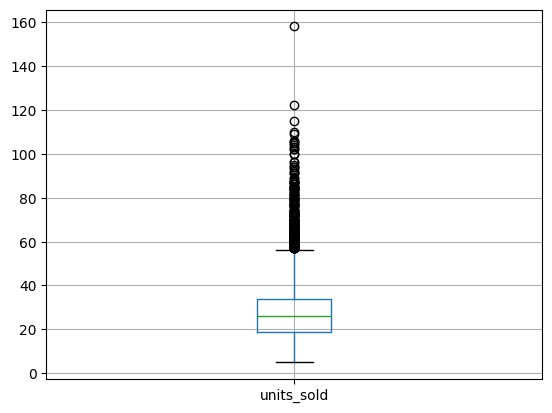

In [ ]:
#  visualizing  outliers using boxplot
df.boxplot(column=['units_sold'])


In [ ]:
#Interpretation:
#       The boxplot indicates that the units_sold variable is positively skewed with numerous high-value outliers,
#       suggesting that while most products have moderate sales, a few products experience exceptionally high demand.

<Axes: >

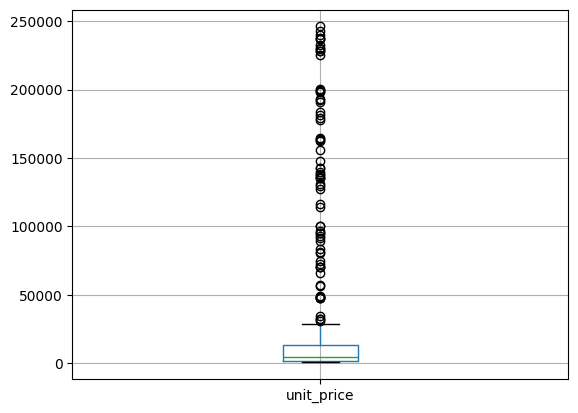

In [ ]:
df.boxplot(column=['unit_price'])

In [ ]:
#Interpretation:
#        The boxplot shows that the unit_price variable is highly right-skewed with many upper outliers,
#        indicating that while most products are moderately priced, a small number of products have exceptionally high prices.

In [ ]:
# detecting outliers programmatically
# detection of outliers
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)   # First quartile (25%)
    Q3 = df[col].quantile(0.75)   # Third quartile (75%)
    IQR = Q3 - Q1                      # Interquartile Range

    lower_bound = Q1 - 1.5 * IQR       # Lower limit for outliers
    upper_bound = Q3 + 1.5 * IQR       # Upper limit for outliers

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f" Column: {col} — Found {len(outliers)} outliers")


 Column: units_sold — Found 289 outliers
 Column: unit_price — Found 71 outliers
 Column: stock_on_hand — Found 151 outliers
 Column: reorder_point — Found 0 outliers
 Column: is_promotion — Found 354 outliers
 Column: discount_pct — Found 354 outliers
 Column: day_of_week — Found 0 outliers
 Column: month — Found 0 outliers
 Column: supplier_lead_days — Found 0 outliers


In [ ]:
# correction of outliers using capping method
# 1. Calculate bounds for unit_price
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping (Winsorization)
df['unit_price'] = df['unit_price'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

# 2. Calculate bounds for stock_on_hand
Q1 = df['stock_on_hand'].quantile(0.25)
Q3 = df['stock_on_hand'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping (Winsorization)
df['stock_on_hand'] = df['stock_on_hand'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

# Reasons for not capping some features
#    1. units sold feature  -->  during discount usually more units are sold.
#    2. is_promotion --->  in this feature 0 s have more rows so it shows 1s as outliers.
#    3. discount_pct ----> in this feature 0.0 discount percentage have more rows so it shows other discount percentage  as outliers.



**Exploratory Data Analysis**

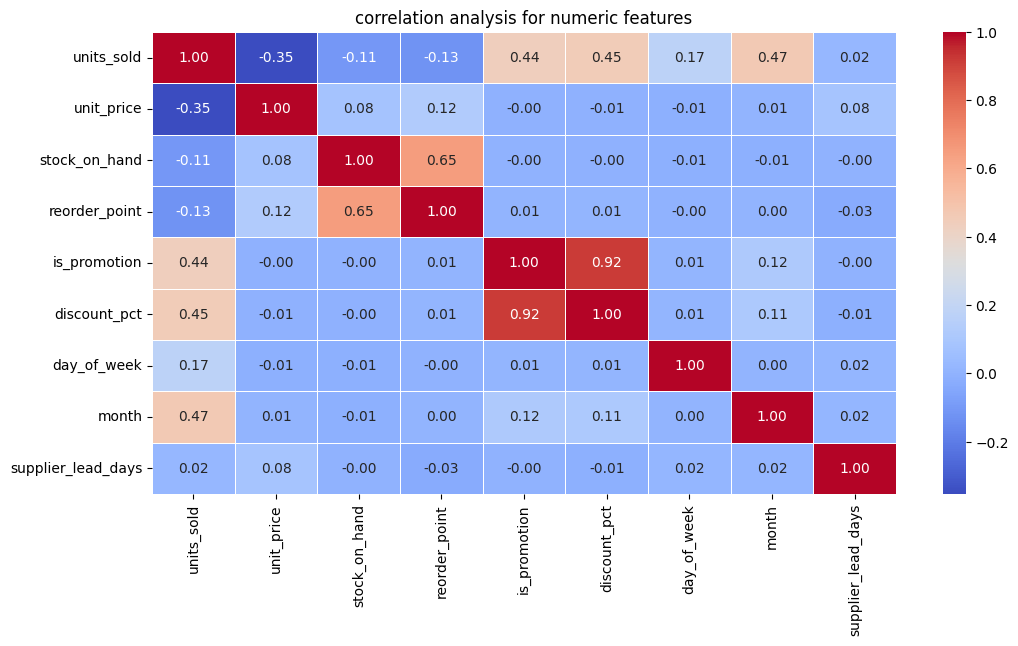

In [ ]:
# 1.correlation analysis
numeric = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric.corr()

plt.figure(figsize=(12,6))
plt.title('correlation analysis for numeric features')
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.show()

In [ ]:
# Insights:
# Strong positive correlation:
#         1.is_promotion ---->  discount_pct (0.92), Very strong relationship.Promotions are almost always tied to higher discounts.
#         2.stock_on_hand ----> reorder_point (0.65), When stock increases, reorder point also increases.
# Moderate positiive correlations:
#         1.units_sold ----> month (0.47), Sales vary by month → possible seasonality effect.
#         2.units_sold ----> discount_pct (0.45), Discounts increase sales).
#         3.units_sold ----> is_promotion (0.44), Promotions significantly boost sales.
# Negative correlation:
#         1.units_sold ----> unit_price (-0.35), As price increases, sales decreases.

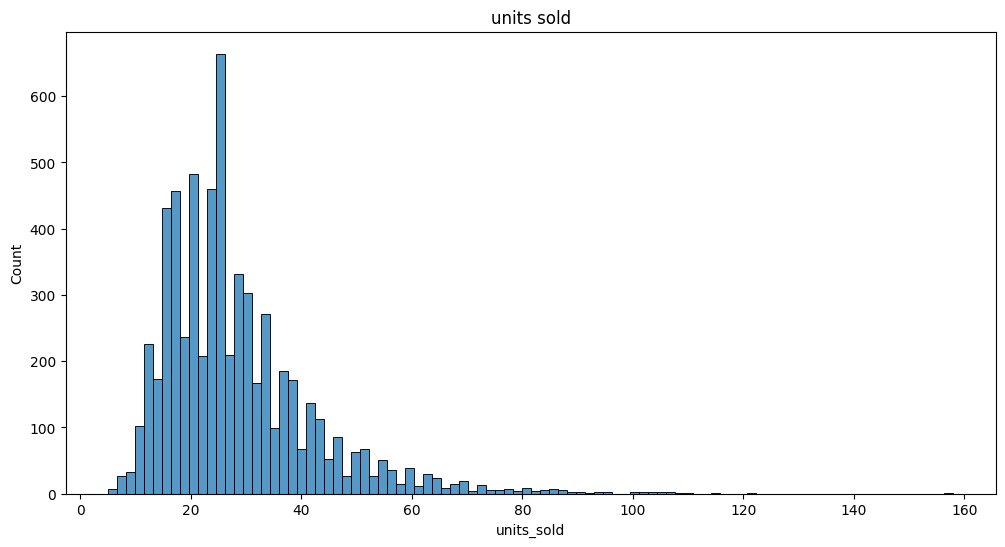

In [ ]:
# visualization for units sold feature by histogram
plt.figure(figsize=(12,6))
plt.title('units sold')
sns.histplot(df['units_sold'])
plt.show()


In [ ]:
#Insights:
# The data is right-skewed (positively skewed),Most values are on the left, with a long tail to the right.
# Most sales fall between 10 to 60 units,The peak appears around 20–30 units.
# There are rare high values going up to 200+ units,This may be due to,
#      1.Special promotions
#      2.Seasonal spikes
#      3.Bulk purchases

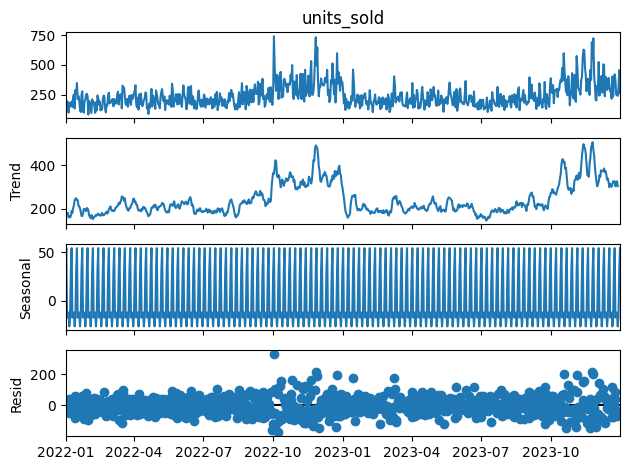

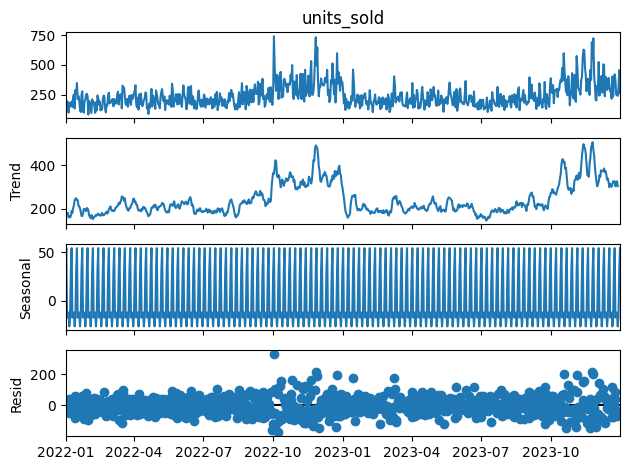

In [ ]:
# Decomposition plots to visualize the seasonality patterns
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)
daily_sales = df.groupby('date')['units_sold'].sum()
decomposition = seasonal_decompose(daily_sales, model='additive', period=7)  # weekly seasonality
decomposition.plot()

In [ ]:
# Insights:
#    1.From early 2022 to late 2022, there is a gradual increase in sales.
#    2.Around early 2023, there is a sharp drop.
#    3.Then again, mid to late 2023 shows recovery and growth.
# Seasonal Component:
#    1.The seasonal plot shows a very strong and consistent repeating pattern.
#    2.The pattern is highly regular which means likely daily or weekly seasonality.
#  Residual (Noise / unexplained variation):
#    1.Residuals are mostly centered around zero but There are some large spikes/outliers
#    2.Variability increases slightly in later periods.
#    3.There are unexpected events or anomalies due to  promotions, holidays, stock issues.

<Figure size 1200x500 with 0 Axes>

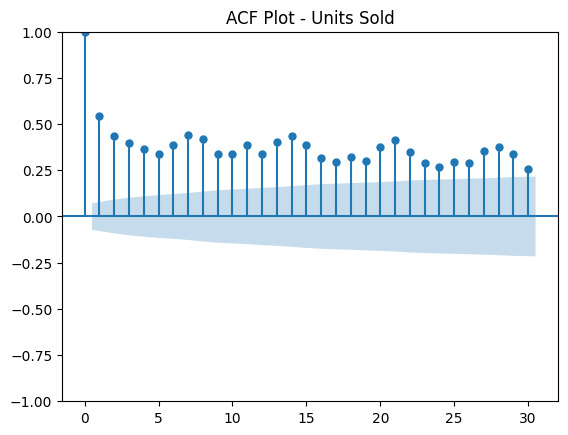

<Figure size 1200x500 with 0 Axes>

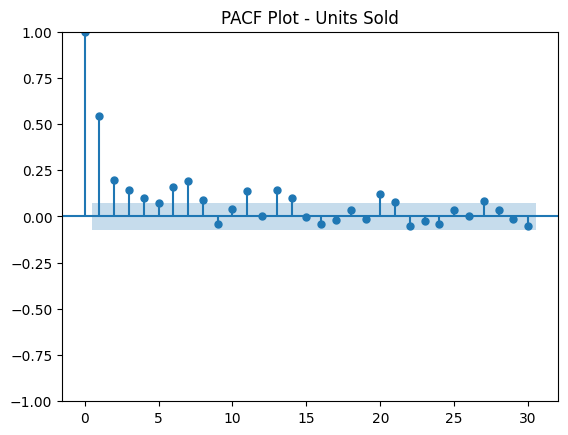

In [ ]:
# ACF (Auto Correlation Function)/PACF (Partial Auto Correlation Function) Plots

# Aggregate daily sales (if multiple entries per day)
ts = df.groupby('date')['units_sold'].sum()

# Plot ACF
plt.figure(figsize=(12,5))
plot_acf(ts, lags=30)
plt.title("ACF Plot - Units Sold")
plt.show()

# Plot PACF
plt.figure(figsize=(12,5))
plot_pacf(ts, lags=30, method='ywm')
plt.title("PACF Plot - Units Sold")
plt.show()

In [ ]:
# Insights:
# Acf plot:
#     1. Strong positive autocorrelation at early lags.The first few lags (lag 1, 2, 3…) have high positive values (0.5 and above).
#     2. This means,Today’s sales are strongly influenced by previous days.
#Pacf plots:
#     1.Strong spike at lag 1,Lag 1 has a very high value (1.0). This indicates,Strong direct relationship with previous day’s sales.
#     2.Data has a strong AR (AutoRegressive) component.
#     3.Significant spike at lag 2,Lag 2 is still above confidence band, but much smaller.
#     4.After lag 2–3 → values drop inside confidence band,Most lags beyond 2 or 3 are insignificant.
#     5.This means,PACF cuts off quickly,Strong sign of AR model behavior.


In [ ]:
# Deriving lag features,rolling mean/std windows, is_weekend and day/month/quarter.

# 1. Lag Features
for lag in [1,2,3,7, 14, 30]:
  df[f'lag_{lag}'] = (df.groupby('product_id')['units_sold'].shift(lag))

# 2. Rolling Statistics
# 7-day rolling
df['rolling_mean_7'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(7).mean()))
df['rolling_std_7'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(7).std()))

# 14-day rolling
df['rolling_mean_14'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(14).mean()))
df['rolling_std_14'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(14).std()))

# 30-day rolling
df['rolling_mean_30'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(30).mean()))
df['rolling_std_30'] = (df.groupby('product_id')['units_sold'].transform(lambda x: x.shift(1).rolling(30).std()))

# 3. Weekend Feature

df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['date'].dt.dayofweek >= 5

# Convert boolean to int (optional: 1 for weekend, 0 for weekday)
df['is_weekend'] = df['is_weekend'].astype(int)

# day/month/quater columns
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# filling the null values for derived features using bfill method
df = df.bfill()

# encoding categorical features
product_mapping = { 'Electronics' : 0, 'Apparel' : 1, 'Sports' : 2, 'Home' : 3, 'Beauty' : 4}
df['product_category'] = df['product_category'].map(product_mapping).astype(int)


In [ ]:
# LSTM model
#dropping date and unique columns

df = df.drop(['date','product_id'], axis=1)

# splitting data

dataset = df.values #convert to numpy array

training_data_len = int(np.ceil(len(dataset) * 0.80))  # 80% training size
train_data = dataset[:training_data_len]
test_data = dataset[training_data_len:]

# scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

X_train, y_train = [], []

# Create a sliding window
# total = 6223
# training_data_count = 4979
# testing_data_count = 1244

window_size = 60
for i in range(window_size, len(scaled_train)):
    X_train.append(scaled_train[i-window_size:i, :])
    y_train.append(scaled_train[i,1])  # 1 represents target column(units sold)


In [ ]:

len(X_train), len(y_train)
X_train, y_train = np.array(X_train), np.array(y_train)

# Build the Model
model = keras.models.Sequential() # Simple stack of layers

# First Layer
model.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Second Layer
model.add(keras.layers.LSTM(128, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(64, activation="relu"))

# 4th Layer (Dropout)
# To prevent the overfitting dropping 20% of neurons
model.add(keras.layers.Dropout(0.2))

# Final Output Layer
model.add(keras.layers.Dense(1))

optimizer = keras.optimizers.Adam(
    learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss="mse",
              metrics=["mae"])

training = model.fit(X_train, y_train, epochs = 50, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 72s 365ms/step - loss: 0.0068 - mae: 0.0563
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 45s 290ms/step - loss: 0.0048 - mae: 0.0492
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 272ms/step - loss: 0.0046 - mae: 0.0470
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 41s 269ms/step - loss: 0.0042 - mae: 0.0453
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 44s 284ms/step - loss: 0.0040 - mae: 0.0446
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 81s 280ms/step - loss: 0.0040 - mae: 0.0440
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 43s 281ms/step - loss: 0.0040 - mae: 0.0438
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 271ms/step - loss: 0.0040 - mae: 0.0437
Epoch 9/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 41s 269ms/step - loss: 0.0038 - mae: 0.0429
Epoch 10/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - loss: 0.0038 - mae: 0.0428
Epoch 11/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 81s 263ms/step - loss: 0.0037 - mae: 0.0424
Epoch 12/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 262ms/step - loss: 0.0038 - m

In [ ]:
# testing
X_test, y_test = [], []

# Combine last window from train with test data
test_input = np.vstack((scaled_train[-window_size:], scaled_test))

for i in range(window_size, len(test_input)):
    X_test.append(test_input[i-window_size:i, :])
    y_test.append(test_input[i, 1])   # target column

X_test = np.array(X_test)
y_test = np.array(y_test)

# make predictions
predictions = model.predict(X_test)

pred_full = np.zeros((len(predictions), scaled_train.shape[1]))
pred_full[:, 1] = predictions.flatten()

actual_full = np.zeros((len(y_test), scaled_train.shape[1]))
actual_full[:, 1] = y_test

predictions_inverse = scaler.inverse_transform(pred_full)[:, 1]
y_test_inverse = scaler.inverse_transform(actual_full)[:, 1]

mask = y_test_inverse != 0

mape = np.mean(np.abs((y_test_inverse[mask] - predictions_inverse[mask])/ y_test_inverse[mask])) * 100
rmse = np.sqrt(mean_squared_error(y_test_inverse, predictions_inverse))
mae = mean_absolute_error(y_test_inverse, predictions_inverse)
r2 = r2_score(y_test_inverse, predictions_inverse)

print("R²  :", r2)
print("MAPE:", mape)
print("RMSE:", rmse)
print("MAE :", mae)




39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step
R²  : 0.5049690674106758
MAPE: 23.654787659476533
RMSE: 9.687504140992965
MAE : 6.376587357192369


In [ ]:
# Reasons for low r score:
#             1.Noise and Data Quality Issues.
#             2.High Randomness in Data.
#             3.Weak Relationship Between Features and Target.
#             4.Limited Dataset Size
#             5.Multiple hyperparameter configurations were evaluated, including variations in LSTM units, epochs, dropout rates, and window sizes.
#  The resulting performance improvements were marginal, indicating that the model had already captured most of the predictive patterns available in the dataset.
#  The remaining unexplained variance is likely due to external factors and inherent randomness in retail demand that are not represented in the available features

In [ ]:
# MLP baseline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Flatten, BatchNormalization


#Model
# 3 Layer Feed Forward Network

model = Sequential([

    Flatten(input_shape=(60, 25)),

    Dense(512, activation='relu'),
    BatchNormalization(),

    Dense(256, activation='relu'),
    BatchNormalization(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1)])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.001),
    loss='mse',
    metrics=['mae'])

model.summary()





/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       768,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,641 (3.60 MB)

 Trainable params: 942,849 (3.60 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Training

history = model.fit(X_train,y_train,validation_split=0.2,
                    epochs=200,batch_size=32)


Epoch 1/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 4.9698e-04 - mae: 0.0167 - val_loss: 0.0066 - val_mae: 0.0560
Epoch 2/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4.4001e-04 - mae: 0.0161 - val_loss: 0.0071 - val_mae: 0.0583
Epoch 3/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.5717e-04 - mae: 0.0163 - val_loss: 0.0061 - val_mae: 0.0535
Epoch 4/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 4.4160e-04 - mae: 0.0158 - val_loss: 0.0061 - val_mae: 0.0537
Epoch 5/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 4.9003e-04 - mae: 0.0164 - val_loss: 0.0060 - val_mae: 0.0542
Epoch 6/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 4.8070e-04 - mae: 0.0166 - val_loss: 0.0064 - val_mae: 0.0544
Epoch 7/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 4.3862e-04 - mae: 0.0158 - val_loss: 0.0064 - val_mae: 0.0555
Epoch 8/200
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 4.5407e-04 - mae: 0.0163 - val_loss: 0.0066 - val_mae: 0.0568
Epoch 9/

In [ ]:
# Prediction

y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2 Score : 0.3357225976066355
MAE      : 0.047612188276446275
RMSE     : 0.07382898265282806


In [ ]:
# justification for fixing a lstm model:
#            LSTM R² = 0.50
#            MLP R² = 0.33
#        1.LSTM networks are specifically designed for sequential and time-series data.
#        2.although the improvement in R² is moderate, the LSTM consistently achieved better predictive performance than the MLP baseline,
#          indicating that temporal information contributes meaningfully to forecasting accuracy.
#        3.LSTM was chosen over the MLP baseline.

In [ ]:
# saving the lstm model

model.save("lstm_model.keras")

# saving the scaler
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
